In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
url = 'https://raw.githubusercontent.com/manasacharyagit/claim-detection/refs/heads/master/medicaldata.csv'
df = pd.read_csv(url)
df.head()

,Client,State,VisitID#,Patient Name,DOS,Aging Days,Aging Bucket,Submitted Date,Insurance Name,Status,Billed Amount,Balance Amount,Primary/Secondary,Type,Status Code,Action Code,Assigned To,Worked By,Worked Date,Follow up date
0,ALT,TX,57089Y520799,"Smith, Emily",11-12-2024,292,181+,12/27/2024,Cigna,Pending,553.21,553.21,Primary,Portal,Pending Follow-up,Follow up with Insurance,Client Assistance,Anna,08/31/2025,09/15/2025
1,HHS,CA,51009H624169,"Brown, Anna",05/28/2024,460,181+,06/30/2024,Humana,No response,407.03,407.03,Secondary,Analyse,Claim not on file,Resubmit claim,Billing Team,Emily,08/31/2025,09-10-2025
2,HHS,CA,28957Z430681,"Taylor, John",12/30/2024,244,181+,02-12-2025,UHC,Claim at insurance,1134.55,1134.55,Primary,Analyse,Claim in Process,Monitor Claim Status,AR Team,Anna,08/31/2025,09-05-2025
3,HHS,CA,44608G733134,"Smith, Emily",06/21/2024,436,181+,08-01-2024,UHC,No response,1104.68,1104.68,Primary,Portal,Other Reason,General Follow-up,AR Team,John,08/31/2025,09-10-2025
4,HHS,CA,26831Y867314,"Lee, Emily",01-11-2024,598,181+,02/18/2024,Aetna,Claim at insurance,519.85,519.85,Primary,Email,Claim in Process,Monitor Claim Status,AR Team,Emily,08/31/2025,09-05-2025


Checking for Null values

In [14]:
df.isnull().sum()

Client               0
State                0
VisitID#             0
Patient Name         0
DOS                  0
Aging Days           0
Aging Bucket         0
Submitted Date       0
Insurance Name       0
Status               0
Billed Amount        0
Balance Amount       0
Primary/Secondary    0
Type                 0
Status Code          0
Action Code          0
Assigned To          0
Worked By            0
Worked Date          0
Follow up date       0
dtype: int64

Checking for Duplicate values

In [15]:
df.duplicated().sum()

np.int64(0)

Keeping only the required features


In [16]:
df = df[['Client', 'Aging Days', 'Insurance Name', 'Status', 'Billed Amount', 'Primary/Secondary', 'Status Code', 'Action Code', 'Assigned To']]\

df.head()

,Client,Aging Days,Insurance Name,Status,Billed Amount,Primary/Secondary,Status Code,Action Code,Assigned To
0,ALT,292,Cigna,Pending,553.21,Primary,Pending Follow-up,Follow up with Insurance,Client Assistance
1,HHS,460,Humana,No response,407.03,Secondary,Claim not on file,Resubmit claim,Billing Team
2,HHS,244,UHC,Claim at insurance,1134.55,Primary,Claim in Process,Monitor Claim Status,AR Team
3,HHS,436,UHC,No response,1104.68,Primary,Other Reason,General Follow-up,AR Team
4,HHS,598,Aetna,Claim at insurance,519.85,Primary,Claim in Process,Monitor Claim Status,AR Team


checking for outliers


In [17]:
numeric_cols = df.select_dtypes(include='number').columns

def outlier_summary(df, cols):
    summary = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        summary[col] = ((df[col] < lower) | (df[col] > upper)).sum()
    
    return pd.DataFrame.from_dict(summary, orient='index', columns=['outlier_count'])

outlier_summary(df, numeric_cols)

,outlier_count
Aging Days,0
Billed Amount,0


Encoding categories - (converting string data in numbers)

In [ ]:
y = df['Status']
X = df.drop('Status', axis = 1)
X = pd.get_dummies(X)  # all x columns apart from target are numeric now


Exploring correlation

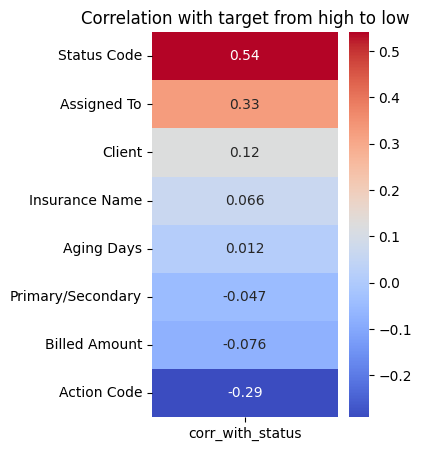

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder



cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = OrdinalEncoder().fit_transform(X[cat_cols]) # encoded the X 

# encode target
y_enc = LabelEncoder().fit_transform(y)

# correlation with target
corr_with_target = X.corrwith(pd.Series(y_enc)).sort_values(ascending=False)


plt.figure(figsize=(3, 5))
sns.heatmap(corr_with_target.to_frame(name='corr_with_status'),
            annot=True, cmap='coolwarm')
plt.title("Correlation with target from high to low")
plt.show()

Scaling the features

In [39]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()

X_scaled = scaler.fit_transform(X) # X_scaled is an array now

X = pd.DataFrame(X_scaled, columns=X.columns) # Converting X to dataframe

X.head()

,Aging Days,Billed Amount,Client_ALT,Client_DSA,Client_HHS,Client_SDS,Insurance Name_Aetna,Insurance Name_Cigna,Insurance Name_Community Health Care,Insurance Name_Humana,...,Action Code_General Follow-up,Action Code_Monitor Claim Status,Action Code_Need coding assistance,Action Code_Post Payment Review,Action Code_Resubmit claim,Assigned To_AR Team,Assigned To_Billing Team,Assigned To_Client Assistance,Assigned To_Coding Team,Assigned To_Payment Team
0,-1.242823,-0.587150,1.732051,-0.608164,-0.615882,-0.507801,-0.428290,2.249579,-0.420084,-0.351562,...,-0.294884,-0.507801,-0.468521,-0.217072,-0.436436,-0.750000,-0.639101,2.645751,-0.468521,-0.217072
1,0.359589,-1.111736,-0.577350,-0.608164,1.623688,-0.507801,-0.428290,-0.444528,-0.420084,2.844452,...,-0.294884,-0.507801,-0.468521,-0.217072,2.291288,-0.750000,1.564697,-0.377964,-0.468521,-0.217072
2,-1.700655,1.499064,-0.577350,-0.608164,1.623688,-0.507801,-0.428290,-0.444528,-0.420084,-0.351562,...,-0.294884,1.969276,-0.468521,-0.217072,-0.436436,1.333333,-0.639101,-0.377964,-0.468521,-0.217072
3,0.130673,1.391872,-0.577350,-0.608164,1.623688,-0.507801,-0.428290,-0.444528,-0.420084,-0.351562,...,3.391165,-0.507801,-0.468521,-0.217072,-0.436436,1.333333,-0.639101,-0.377964,-0.468521,-0.217072
4,1.675855,-0.706867,-0.577350,-0.608164,1.623688,-0.507801,2.334869,-0.444528,-0.420084,-0.351562,...,-0.294884,1.969276,-0.468521,-0.217072,-0.436436,1.333333,-0.639101,-0.377964,-0.468521,-0.217072


Splitting Data in train and test

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, test_size=0.3, random_state=2)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(140, 48)
(60, 48)
(140,)
(60,)


Training on model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfmodel = RandomForestClassifier(n_estimators=100, random_state=2)

rfmodel.fit(X_train, y_train) # fitting our train data

y_pred = rfmodel.predict(X_test) # putting our test data to get the prediction

print(y_pred)

['No response' 'Pending' 'Denied' 'Pending' 'Error' 'Denied' 'Denied'
 'Denied' 'No response' 'Denied' 'Error' 'Error' 'Denied' 'Denied'
 'Denied' 'Claim at insurance' 'Claim at insurance' 'Claim at insurance'
 'Pending' 'Denied' 'Denied' 'Denied' 'Claim at insurance'
 'Claim at insurance' 'Pending' 'Claim at insurance' 'No response'
 'Denied' 'Claim at insurance' 'Pending' 'Claim at insurance'
 'Claim at insurance' 'Pending' 'Error' 'Claim at insurance' 'Error'
 'Denied' 'Claim at insurance' 'Denied' 'Denied' 'Denied'
 'Claim at insurance' 'Pending' 'No response' 'Claim at insurance'
 'Denied' 'No response' 'Pending' 'Denied' 'No response' 'Denied'
 'Claim at insurance' 'Error' 'Claim at insurance' 'Denied' 'No response'
 'Denied' 'Claim at insurance' 'Denied' 'Denied']
